# Промежуточная аттестация 1
### _• Выберите и распакуйте одну из предлагаемых баз данных, либо предложите свою (если имеется)_
В организации ведется учёт выдачи, возврата и списания инструмента, имеется база данных и представление faadocs со следующими полями
* Key_Mat – идентификатор записи
* Number – номер документа
* Date – Дата документа
* FromName – отправитель (склад, кладовая, сотрудник)
* ToName – получатель (склад, кладовая, сотрудник)
* FullNameBuh – наименование инструмента
* Price – Цена, руб.
* Qty – Количество
### _• Для предметной области, которую моделирует выбранная база данных, предложите бизнес-задачу_
Предметная область: Управление запасами инструмента используемого в производстве.

Бизнес-задача: Определение какой инструмент и когда пора закупать, снижение дефицита, избегание затоваривания склада, оптимизация бюджета на закупку инструмента. Выявление причины выхода из строя инструмента (низкое качество инструмента, человеческий фактор, естественный износ).
### _• На основе выбранной предложенной бизнес-задачи сформулируйте задачу машинного обучения, которую бы вы могли решить с помощью этой_
Бинарная классификация (бинарная задача): Необходимо спрогнозировать для каждого движения инструмента, будет ли этот инструмент списан (по разным причинам полностью использован, утерян, испорчен, …) в скором времени или он останется в обороте. Чтобы заранее заказать новый инструмент, таким образом избежать простоя производства. Или другая ситуация выявить инструмент с длительным пролёживанием.
### _• Предложите целевую переменную и объясняющие признаки, которые позволят вам решить эту задачу_
Для решения задачи прогноза невозврата можно использовать модель бинарной классификации

Целевая переменнная: is_written_off - признак списания, формируется логически при ToName = "Корзина списанных МБП ИК"

- is_written_off = 1 инструмент списан
- is_written_off = 0 инструмент в работе (может находиться как на кладовой так и у сотрудника)
### _• Создайте представление VIEW, которое будет рассчитывать указанные вами показатели_
Данные будут выгружены из производственной базы в чистом виде для последующей обработки в Python.
### _• Из созданного представления выгрузите таблицу в формате xlsx или csv (либо прямо в Pandas)_
Данные были выгружены для удобства работы в parquet-файл следующим скриптом
``` python
import pandas as pd
import pyodbc

connect_str = (
  "DRIVER={ODBC Driver 17 for SQL Server};"
  "SERVER=myserver;"
  "DATABASE=mydb;"
  "Trusted_Connection=yes;"
)

sql_query = "select Key_Mat, Number, Date, FromName, ToName, FullNameBuh, Price, Qty from faadocs where 18266 in (Key_SubDeptFrom, Key_SubDeptTo)"
filename = "data.parquet"

try:
  with pyodbc.connect(connect_str) as conn:
    df = pd.read_sql(sql_query, conn)
    df.to_parquet(filename, engine='pyarrow', index=False)

except Exception as e:
  print(f"Ошибка: {e}")
```
### _• Проведите разведочный анализ данных для выбранных переменных_

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [34]:
# 1. Загрузка данных сформированных представлением (предполагаем, что ты читаешь свой файл)
df = pd.read_parquet('data.parquet')
df.head()

,Key_Doc,Name_K,Number,Date,FromName,ToName,FullNameBuh,Price,Qty
id,,,,,,,,,
473642,640770,АС,АС-11-904-0010,2011-04-29 00:00:00,Инструментальная кладовая,Корзина списанных МБП ИК,"Зенкер Р18 НАС Ф40,0",224.24,1.0
106589,430623,ТН,28,2003-04-29 12:30:00,Инструментальный склад,Инструментальная кладовая,"Зенкер Р18 НАС Ф40,0",224.24,1.0
106581,430623,ТН,28,2003-04-29 12:30:00,Инструментальный склад,Инструментальная кладовая,"Зенкер ВК8 НАС Ф32,0",117.46,5.0
1032992,1383866,АС,АС-14-904-0021,2014-12-31 15:00:00,Инструментальная кладовая,Корзина списанных МБП ИК,"Зенкер ВК8 НАС Ф32,0",117.46,1.0
473643,640770,АС,АС-11-904-0010,2011-04-29 00:00:00,Инструментальная кладовая,Корзина списанных МБП ИК,"Зенкер ВК8 НАС Ф40,0",249.18,1.0


Описание

In [35]:

# Преобразуем даты
df['Date'] = pd.to_datetime(df['Date'])

# Сортировка для корректного расчета жизненного цикла
df_sorted = df.sort_values(['Date', 'id'])

# Расчет дней владения инструментом каждым сотрудником
df_sorted['Next_Date'] = df_sorted.groupby('FullNameBuh')['Date'].shift(-1)
df_sorted['Days_In_Possession'] = (df_sorted['Next_Date'] - df_sorted['Date']).dt.days

# Заполняем пропуски для последнего владельца инструмента (до текущего момента)
today = pd.Timestamp.now()
df_sorted.loc[df_sorted['Days_In_Possession'].isna(), 'Days_In_Possession'] = (today - df_sorted['Date']).dt.days

### _• Проведите очистку данных от пропусков, выбросов и некорректных значений любым выбранным способом._

# Обоснование: Отрицательные Qty - это ошибки ввода или специфические возвраты, которые ломают агрегацию. Это ошибки старой информации базы. Со временем программа дорабатывалась и данные ошибки ушли.
# Даты вне адекватного диапазона (например, 1970 или 2050) - сбои 1С.
df_sorted = df_sorted[df_sorted['Qty'] > 0]
df_sorted = df_sorted[(df_sorted['Date'].dt.year >= 2000) & (df_sorted['Date'].dt.year <= 2026)]

# Извлечение категории инструмента
def get_category(name):
    if pd.isna(name): return 'Unknown'
    return str(name).split()[0] # Берем первое слово (Зенкер, Бокорезы, Втулка)

df_sorted['Tool_Category'] = df_sorted['FullNameBuh'].apply(get_category)
df_sorted['Month'] = df_sorted['Date'].dt.to_period('M')

# Агрегация
writeoffs = df_sorted[df_sorted['Name_K'] == 'АС'].groupby(['Month', 'Tool_Category']).agg(WriteOff_Qty=('Qty', 'sum')).reset_index()
issues = df_sorted[(df_sorted['Name_K'] == 'К/И') & (df_sorted['FromName'].str.contains('кладовая', case=False, na=False))].groupby(['Month', 'Tool_Category']).agg(
    Issuance_Qty=('Qty', 'sum'),
    Unique_Users=('ToName', 'nunique'),
    Avg_Price=('Price', 'mean')
).reset_index()

# Объединяем в итоговый датасет для ML
ml_df = pd.merge(issues, writeoffs, on=['Month', 'Tool_Category'], how='left').fillna(0)

# Разведочный анализ
print("Структура данных:")
print(df_sorted.info())
print("\nОписательная статистика цен:")
print(df_sorted['Price'].describe())


Структура данных:
<class 'pandas.core.frame.DataFrame'>
Index: 148394 entries, 17049 to 2547329
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Key_Doc             148394 non-null  int64         
 1   Name_K              148394 non-null  object        
 2   Number              148394 non-null  object        
 3   Date                148394 non-null  datetime64[ns]
 4   FromName            148330 non-null  object        
 5   ToName              148374 non-null  object        
 6   FullNameBuh         148382 non-null  object        
 7   Price               148394 non-null  float64       
 8   Qty                 148394 non-null  float64       
 9   Next_Date           132731 non-null  datetime64[ns]
 10  Days_In_Possession  148394 non-null  float64       
 11  Tool_Category       148394 non-null  object        
 12  Month               148394 non-null  period[M]     
dtypes: datetime

### _• Постройте графики, которые бы давали представление о связи выбранных переменных_

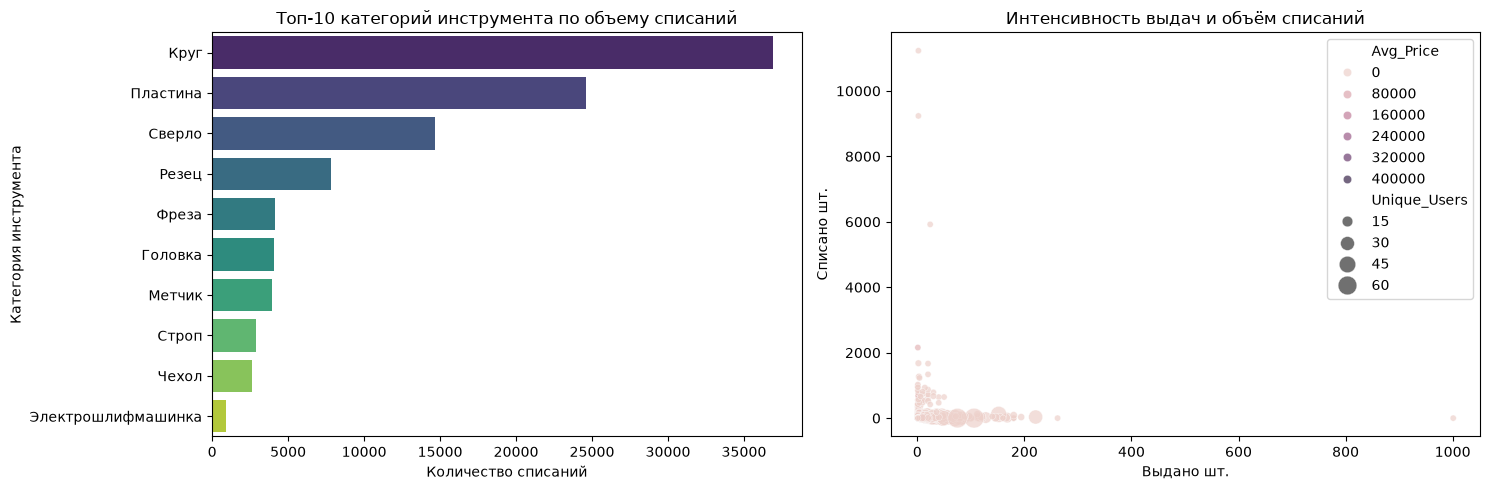

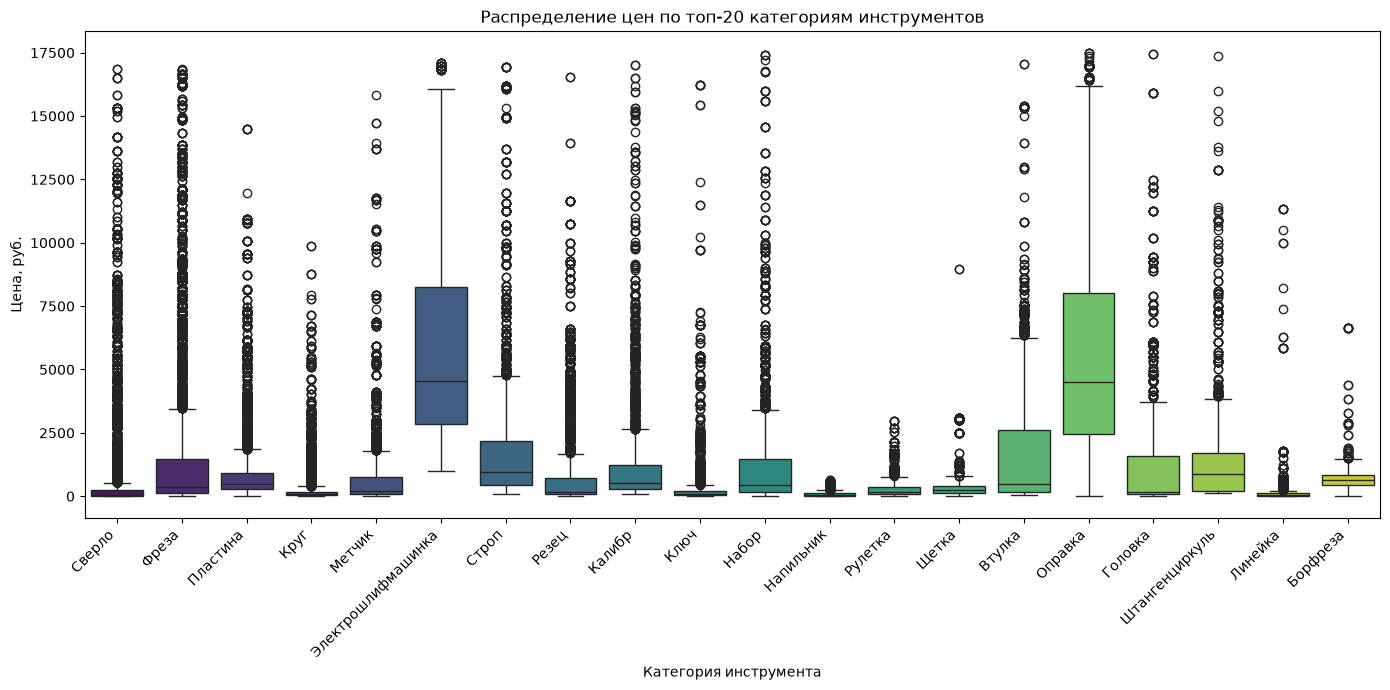

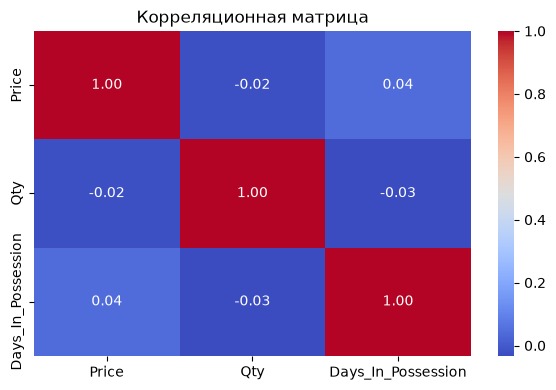

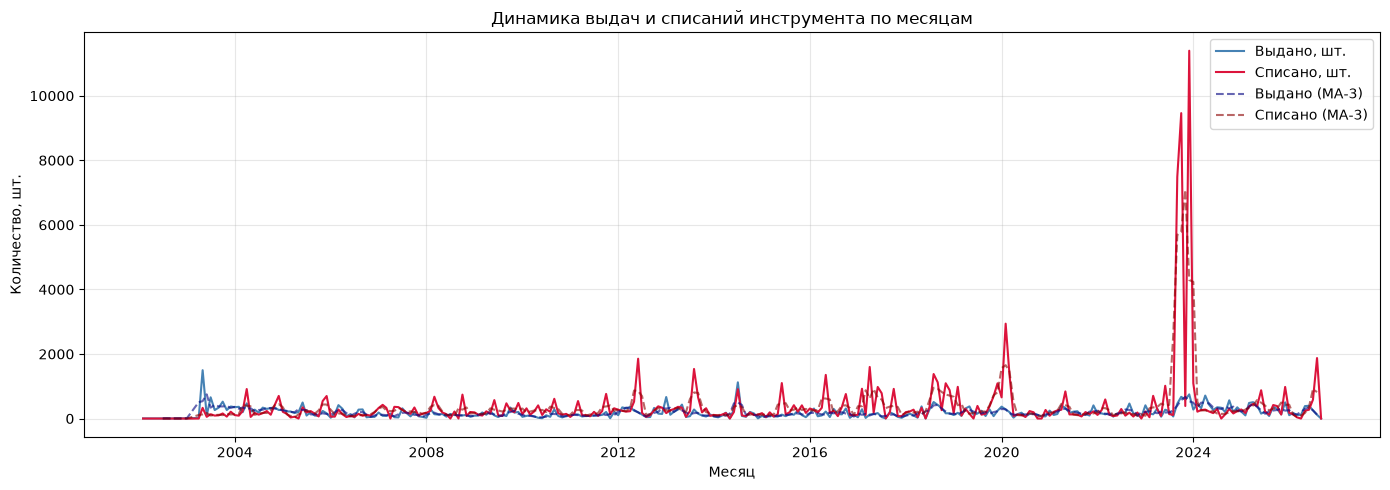

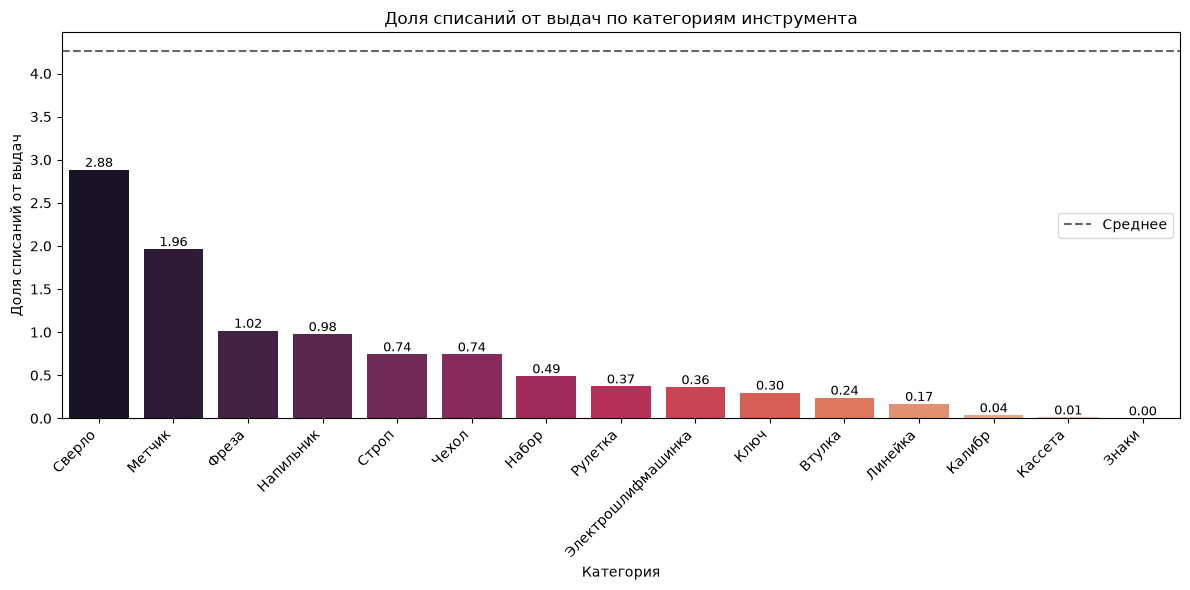

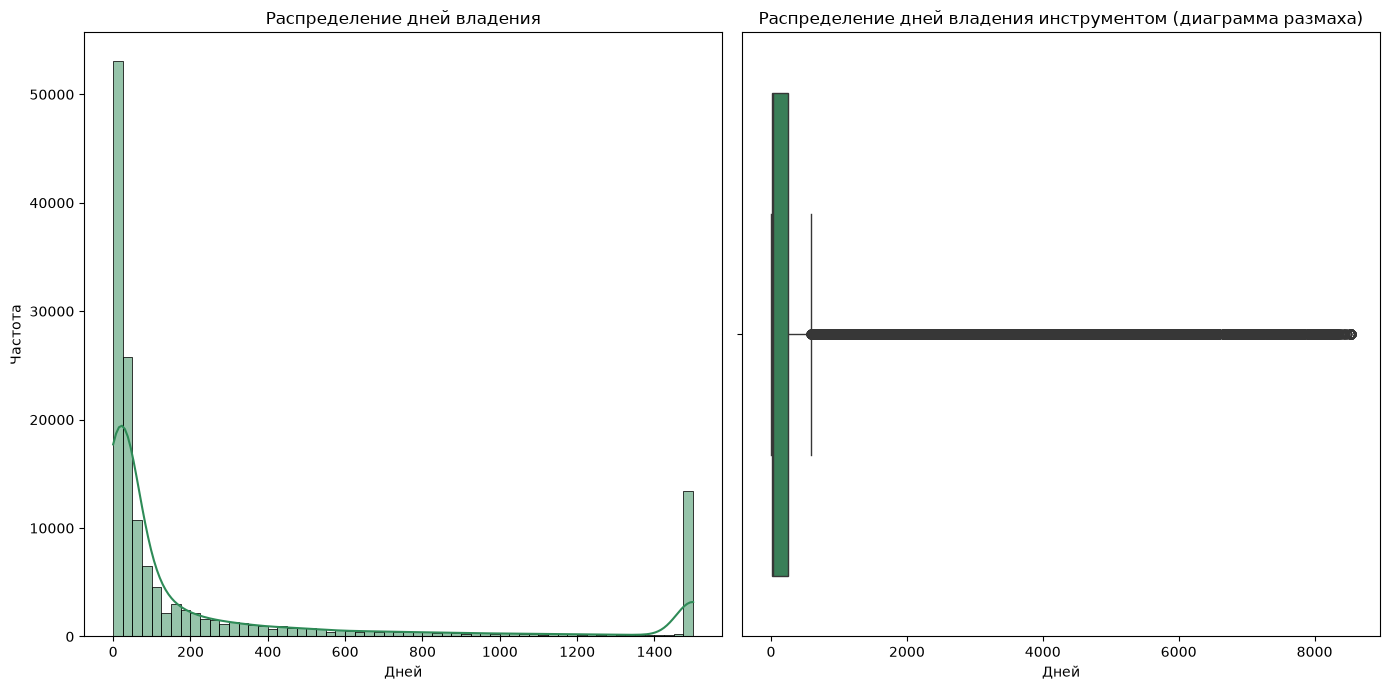

Доля записей со сроком владения > 365 дней: 20.52%


In [36]:
plt.figure(figsize=(15, 5))

# График 1: Топ-10 "убиваемых" категорий инструмента
top_tools = ml_df.groupby('Tool_Category')['WriteOff_Qty'].sum().nlargest(10)
plt.subplot(1, 2, 1)
#sns.set_theme(style="whitegrid")
#sns.barplot(x=top_tools.values, y=top_tools.index, palette='magma')
sns.barplot(x=top_tools.values, y=top_tools.index, palette='viridis')
plt.title('Топ-10 категорий инструмента по объему списаний')
plt.xlabel('Количество списаний')
plt.ylabel('Категория инструмента')
#plt.grid(True)

# График 2: Связь интенсивности использования и списаний
plt.subplot(1, 2, 2)
sns.scatterplot(data=ml_df, x='Issuance_Qty', y='WriteOff_Qty', hue='Avg_Price', size='Unique_Users', sizes=(20, 200), alpha=0.7)
plt.title('Интенсивность выдач и объём списаний')
plt.xlabel('Выдано шт.')
plt.ylabel('Списано шт.')

plt.tight_layout()
plt.show()

# График распределения цен по категориям инструментов
# Выбираем 20 самых частых категорий
top_20_categories = df_sorted['Tool_Category'].value_counts().nlargest(20).index
df_top20 = df_sorted[df_sorted['Tool_Category'].isin(top_20_categories)]
# Ограничиваем выбросы по цене для наглядности (например, 99-й перцентиль)
price_cap = df_top20['Price'].quantile(0.99)
df_top20 = df_top20[df_top20['Price'] <= price_cap]

plt.figure(figsize=(14, 7))
sns.boxplot(x='Tool_Category', y='Price', data=df_top20, order=top_20_categories, palette='viridis')
plt.title('Распределение цен по топ-20 категориям инструментов')
plt.xlabel('Категория инструмента')
plt.ylabel('Цена, руб.')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Тепловая матрица корреляций (для числовых признаков)
numeric_cols = ['Price', 'Qty', 'Days_In_Possession']
corr_matrix = df_sorted[numeric_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

# Динамика списаний и выдач по месяцам
# видно сезонность (например, пик списаний в конце квартала/года) и общий тренд. 
monthly = ml_df.groupby('Month').agg(
    Issuance=('Issuance_Qty', 'sum'),
    WriteOff=('WriteOff_Qty', 'sum')
).reset_index()
monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly['Month_dt'], monthly['Issuance'],
         label='Выдано, шт.', color='steelblue', linewidth=1.5)
plt.plot(monthly['Month_dt'], monthly['WriteOff'],
         label='Списано, шт.', color='crimson', linewidth=1.5)

plt.plot(monthly['Month_dt'],
         monthly['Issuance'].rolling(3, center=True).mean(),
         color='navy', linestyle='--', alpha=0.6, label='Выдано (MA-3)')
plt.plot(monthly['Month_dt'],
         monthly['WriteOff'].rolling(3, center=True).mean(),
         color='darkred', linestyle='--', alpha=0.6, label='Списано (MA-3)')

plt.title('Динамика выдач и списаний инструмента по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество, шт.')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Доля списаний от выдач по топ-15 категориям
cat_stats = ml_df.groupby('Tool_Category').agg(
    Issuance=('Issuance_Qty', 'sum'),
    WriteOff=('WriteOff_Qty', 'sum')
).reset_index()

# Оставляем только категории с заметным объёмом выдач, чтобы избежать шума
cat_stats = cat_stats[cat_stats['Issuance'] >= 50].copy()
cat_stats['WriteOff_Rate'] = cat_stats['WriteOff'] / cat_stats['Issuance']

top15 = cat_stats.nlargest(15, 'Issuance')

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top15, x='Tool_Category', y='WriteOff_Rate',
    palette='rocket', order=top15.sort_values('WriteOff_Rate', ascending=False)['Tool_Category']
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Доля списаний от выдач по категориям инструмента')
plt.xlabel('Категория')
plt.ylabel('Доля списаний от выдач')

plt.xticks(rotation=45, ha='right')
plt.axhline(cat_stats['WriteOff_Rate'].mean(),
            color='black', linestyle='--', alpha=0.6, label='Среднее')
plt.legend()
plt.tight_layout()
plt.show()

# Распределение времени владения инструментом
# Также этот график показывает, есть ли такая проблема в данных и какая доля записей попадает в «красную зону»
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.histplot(df_sorted['Days_In_Possession'].clip(upper=1500),
             bins=60, kde=True, color='seagreen')
plt.title('Распределение дней владения')
plt.xlabel('Дней')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_sorted['Days_In_Possession'], color='seagreen')
plt.title('Распределение дней владения инструментом (диаграмма размаха)')
plt.xlabel('Дней')

plt.tight_layout()
plt.show()

# Сколько движений "висят" дольше года => это явный маркер "пролёживания"
long_hold = (df_sorted['Days_In_Possession'] > 365).mean()
print(f'Доля записей со сроком владения > 365 дней: {long_hold:.2%}')


### _• Сформулируйте на базе рассчитанных переменных гипотезы об их влиянии на выбранную целевую переменную_
На основе построенных графиков и логики мы можем выдвинуть следующие гипотезы:

Гипотеза 1: Инструменты с низкой ценой списываются чаще.
Гипотеза 2: Чем дольше инструмент находится в движении (срок службы), тем выше вероятность списания.
Гипотеза 3: Инструменты типа "Зенкер" списываются реже, чем "Бокорезы".

### _• Для каждой гипотезы постарайтесь привести логический смысл, почему вы считаете, что эта взаимосвязь должна существовать и какую форму взаимосвязи вы ожидаете. Что это дает с практической точки зрения?_

Логический смысл гипотезы 1: Дешевый инструмент проще и дешевле заменить, чем ремонтировать, обычно это расходники диски, дешевые фрезы и т.д. Поэтому его выбрасывают при первых признаках износа, а зачастую выдают и одновременно списывают. Наблюдается отрицательная корреляция :чем выше цена, тем реже списание. В итогде вывод закупать дешевый инструмент лучше партиями.

Логический смысл гипотезы 2: Это естественный износ. Чем старше инструмент, тем больше он выработал свой ресурс. Имеет положительную корреляцию, т.е. у списанных инструментов Lifetime_Days значительно больше. Получается, что если инструменту больше 500 дней, модель будет ставить высокий риск списания.

Логический смысл гипотезы 3: Зенкеры — это режущий инструмент для обработки металла, они имеют много лезвий и могут перетачиваться, т.е. повторно использоваться. Бокорезы — режущий инструмент (кусачки), они не восстанавливаются, ломаются быстрее, режущая часть одна. Эта форма имеет зависимость от категории. На графике столбец Зенкер будет ниже, чем Бокорезы. Помогает формировать разные признаки износа запасов для разных категорий.
